# Humpback Whale Identification — Triplet Loss Metric Learning

**Course**: Machine Learning for Computer Vision (91266)  
**Task**: [Kaggle Whale Identification Playground](https://www.kaggle.com/competitions/whale-categorization-playground)  
**Authors**: Kristoffer Osen & Sebastian Munthe


## Setup

In [ ]:
import sys
import os
import torch
import json
from dataset import build_retrieval_eval_loaders
from dataset import get_eval_config_and_data
from visualization import plot_embedding_tsne


sys.path.insert(0, os.path.dirname(os.path.abspath("__file__")))

from config import ExperimentConfig
from experiment import ExperimentManager
from dataset import (
    prepare_data,
    build_metric_dataloaders,
 )
from models import build_model
from training import train
from evaluation import evaluate_retrieval
from visualization import plot_training_history

device = torch.device("cuda" if torch.cuda.is_available()
                      else "mps" if hasattr(torch.backends, "mps") and torch.backends.mps.is_available()
                      else "cpu")
print(f"Device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Device: cpu


## Triplet Loss Training

**Triplet Loss** (Schroff et al., FaceNet, CVPR 2015 — course slides 21–24) directly
optimizes embedding distances. For each triplet (anchor, positive, negative):

$$L(A, P, N) = \max\{0,\ \|f(A) - f(P)\|^2 - \|f(A) - f(N)\|^2 + m\}$$

Key implementation details:
- **Semi-hard negative mining**: negatives that are farther than the positive but within
  the margin — provides the most useful gradient signal.
- **Limitation**: classes with only 1 image cannot participate (no positive pair possible).
  This significantly reduces the usable training set — a real limitation worth discussing.

The model uses `head_type="none"` — no classifier, only the L2-normalized embedding.


In [ ]:
config = ExperimentConfig(
    # ── Metadata ─────────────────────────────────────────────────
    experiment_name="triplet_effnetb5",
    description="Triplet loss with semi-hard mining, open-set random sampling",

    # ── Paths ────────────────────────────────────────────────────
    data_dir="data",
    experiments_root="experiments",

    # ── Model ────────────────────────────────────────────────────
    backbone="efficientnet_b5",
    image_size=(456, 456),
    embedding_dim=512,
    head_type="none",          # ← No classifier, embedding-only

    # ── Training ─────────────────────────────────────────────────
    freeze_backbone_epochs=2,
    freeze_bn=True,
    epochs=20,
    batch_size=16,            # Open-set random batch size
    accumulation_steps=1,      # No extra accumulation for large batches
    use_amp=True,

    # ── Loss ─────────────────────────────────────────────────────
    loss_type="triplet",
    triplet_margin=0.3,
    triplet_mining="semi_hard",
    use_class_weights=False,   # Not applicable for triplet loss

    # ── Optimizer ────────────────────────────────────────────────
    lr_head=5e-4,
    lr_backbone=5e-5,
    weight_decay=1e-4,

    # ── Scheduler ────────────────────────────────────────────────
    scheduler="cosine",
    warmup_epochs=1,

    # ── Early stopping ───────────────────────────────────────────
    early_stopping_patience=6,
    early_stopping_metric="retrieval_recall@1",

    # ── Initialize from baseline ─────────────────────────────────
    init_from_checkpoint=BASELINE_CHECKPOINT if 'BASELINE_CHECKPOINT' in dir() else None,

    seed=42,
 )

print("Triplet config:")
print(config.summary())


Triplet config:
efficientnet_b5 | 456px | triplet(γ=2.0) | lr=5e-05/0.0005 | freeze=2ep | bs=8×2 | head=none | triplet(m=0.3,semi_hard) | PK(4×4)


## Data Preparation

In [ ]:
data = prepare_data(config)

print(f"\nClass mapping: {data['num_classes']} known whale identities")
print(f"ID → Index examples: {dict(list(data['id_to_idx'].items())[:5])} ...")

[split] Stratified test split infeasible on frequent classes; using shuffled split.
[split] Stratified val split infeasible on frequent classes; using shuffled split.
Dataset split:
  Train:    8089 images, 4247 known classes (filtered 647 new_whale)
  Val:       557 images (88 are new_whale)
  Test:      557 images (75 are new_whale)
  Class distribution: min=1 median=1 max=24 samples/class

Class mapping: 4247 known whale identities
ID → Index examples: {'w_0013924': 0, 'w_001ebbc': 1, 'w_002222a': 2, 'w_002b682': 3, 'w_002dc11': 4} ...


## Train

In [ ]:
TRAINING_ENABLED = False
EXPERIMENT_ID = "20260404_143337_triplet_effnetb5_3ae3db53"

if TRAINING_ENABLED:
    # manager = train(config, data, device, resume_from=EXPERIMENT_ID)
    manager = train(config, data, device)
else:
    print("Skipping training")
    config = ExperimentConfig.load("experiments/" + EXPERIMENT_ID + "/config.json")
    manager = ExperimentManager(config, EXPERIMENT_ID)

Skipping training


## Training analysis

c:\Users\Sebastian Munthe\Desktop\ml4cv_final\ML4CV\visualization.py:75: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="upper left")


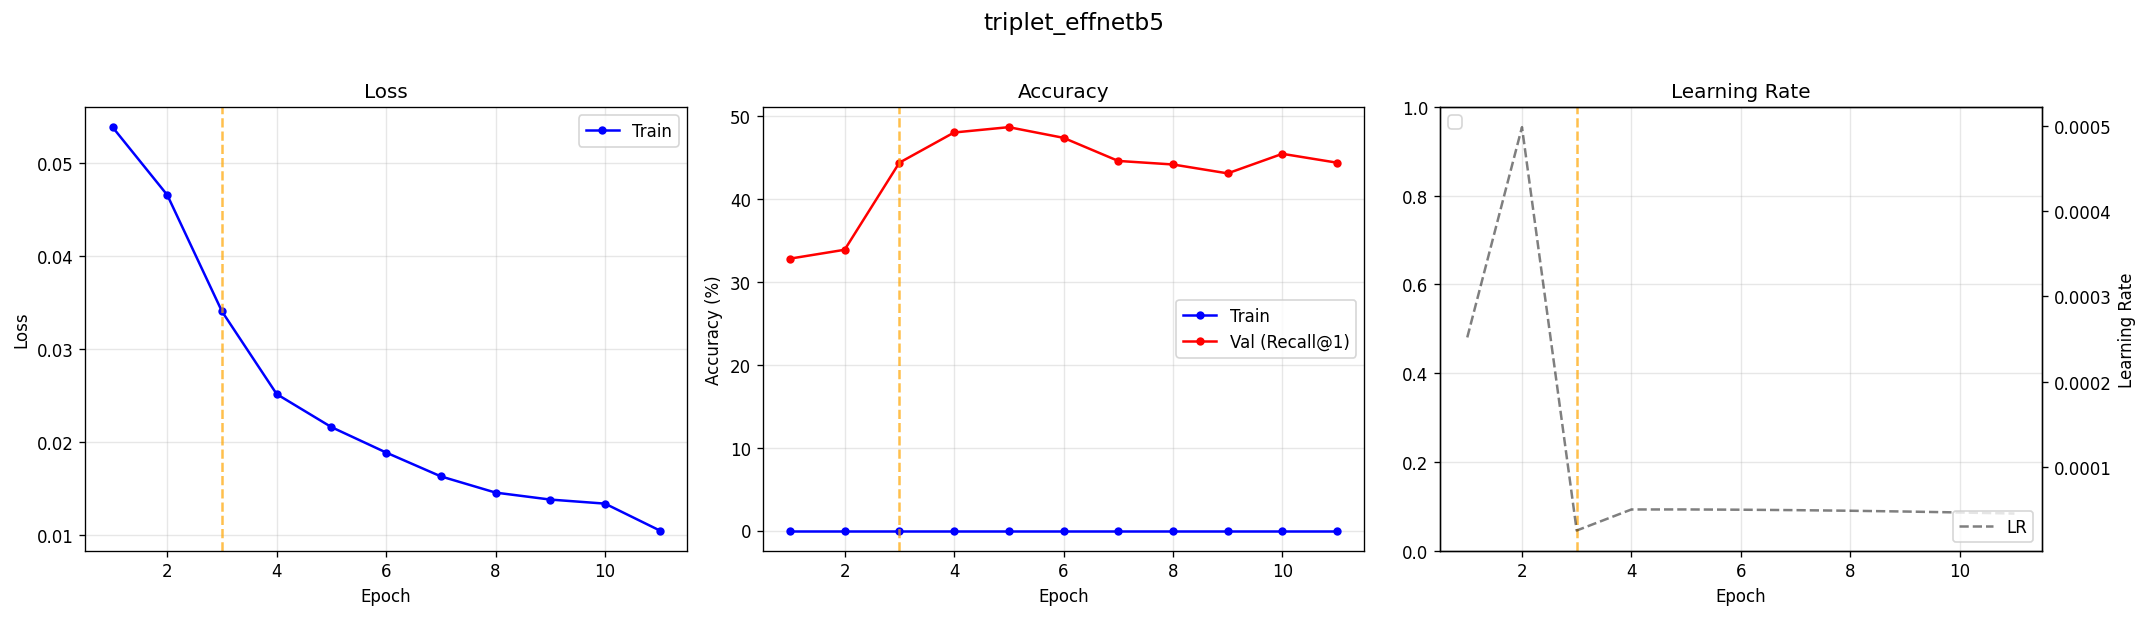

In [ ]:
metrics_path = manager.root / "metrics.json"

with open(metrics_path, "r") as f:
    metrics = json.load(f)

plot_training_history(metrics, title=config.experiment_name)

In [ ]:
print("\nFinal metrics (last epoch):")
for key in ["retrieval_recall@1", "retrieval_recall@5", "train_loss"]:
    if key in metrics:
        val = metrics[key][-1]
        if "acc" in key or "detection" in key or "recall" in key:
            print(f"  {key:<30s}: {val * 100:.2f}%")
        else:
            print(f"  {key:<30s}: {val:.4f}")



Final metrics (last epoch):
  retrieval_recall@1            : 44.33%
  retrieval_recall@5            : 58.89%
  train_loss                    : 0.0105


### Embedding quality

In [ ]:
eval_config, data = get_eval_config_and_data()

triplet_model = build_model(config, data["num_classes"], device)
manager.load_checkpoint(triplet_model, checkpoint="best")

train_loader, val_loader = build_retrieval_eval_loaders(eval_config, data)

print("Triplet retrieval performance:")
triplet_retrieval = evaluate_retrieval(
    triplet_model, train_loader, val_loader, eval_config, device,
)

plot_embedding_tsne(triplet_model, val_loader, data, device,
                    title="Triplet Loss Embedding — t-SNE", combine_loaders=[train_loader])

[split] Stratified test split infeasible on frequent classes; using shuffled split.
[split] Stratified val split infeasible on frequent classes; using shuffled split.
Dataset split:
  Train:    8089 images, 4247 known classes (filtered 647 new_whale)
  Val:       557 images (88 are new_whale)
  Test:      557 images (75 are new_whale)
  Class distribution: min=1 median=1 max=24 samples/class
Loading backbone + embedding from: experiments/20260402_175215_baseline_effnetb5_focal_bd5dccca/checkpoints/best.pth
  Loaded 859 parameter tensors (backbone + embedding)
[23:19:35] Loading checkpoint: experiments\20260404_143337_triplet_effnetb5_3ae3db53\checkpoints\best.pth
[23:19:36] Resuming from epoch 5
Triplet retrieval performance:


c:\Users\Sebastian Munthe\Desktop\ml4cv_final\ML4CV\.venv\Lib\site-packages\torch\utils\data\dataloader.py:1095: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


KeyboardInterrupt: 